<a href="https://colab.research.google.com/github/NathanMagno/energy-consumers-data/blob/ex-26-30/cp04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sb
import pandas as pd

Convertendo o dataset em um dataframe pandas

In [ ]:
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)

1 - Mostrando as 10 primeiras linhas do data frame

In [ ]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


2 - A Global_active_power é a potência que realiza trabalho útil, convertida em calor, luz ou movimento pelos aparelhos, é o que você paga na conta de luz. Já a Global_reactive_power é a energia que circula em equipamentos como motores e transformadores para criar campos necessários ao seu funcionamento, mas não realiza trabalho útil diretamente. Ou seja, potência ativa faz o trabalho, enquanto a reativa é um suporte para certas cargas.

3 - Valores faltantes



In [ ]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,3946


4 - Conversão de date para DateTime

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day_of_Week'] = df['Date'].dt.day_name()
display(df.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
0,2006-12-16,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,Saturday
1,2006-12-16,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,Saturday
2,2006-12-16,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,Saturday
3,2006-12-16,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,Saturday
4,2006-12-16,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,Saturday


5 - Filtrar registros e calculo de média

In [ ]:
''' filtre os regristros apenas do ano de 2007  '''
df_2007 = df[df['Date'].dt.year == 2007]
df_2007

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
21996,2007-01-01,00:00:00,2.580,0.136,241.970,10.600,0.000,0.000,0.0,Monday
21997,2007-01-01,00:01:00,2.552,0.100,241.750,10.400,0.000,0.000,0.0,Monday
21998,2007-01-01,00:02:00,2.550,0.100,241.640,10.400,0.000,0.000,0.0,Monday
21999,2007-01-01,00:03:00,2.550,0.100,241.710,10.400,0.000,0.000,0.0,Monday
22000,2007-01-01,00:04:00,2.554,0.100,241.980,10.400,0.000,0.000,0.0,Monday
...,...,...,...,...,...,...,...,...,...,...
547591,2007-12-31,23:55:00,1.746,0.204,242.410,7.200,0.000,0.000,18.0,Monday
547592,2007-12-31,23:56:00,1.732,0.210,242.420,7.200,0.000,0.000,18.0,Monday
547593,2007-12-31,23:57:00,1.732,0.210,242.500,7.200,0.000,0.000,18.0,Monday
547594,2007-12-31,23:58:00,1.684,0.144,242.180,7.000,0.000,0.000,18.0,Monday


In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df_2007['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df.info()

/tmp/ipython-input-1006180630.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2007['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831838 entries, 0 to 831837
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   831838 non-null  datetime64[ns]
 1   Time                   831838 non-null  object        
 2   Global_active_power    827893 non-null  float64       
 3   Global_reactive_power  831838 non-null  object        
 4   Voltage                831838 non-null  object        
 5   Global_intensity       831838 non-null  object        
 6   Sub_metering_1         831838 non-null  object        
 7   Sub_metering_2         831838 non-null  object        
 8   Sub_metering_3         827892 non-null  float64       
 9   Day_of_Week            831838 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 63.5+ MB


In [ ]:
df_2007.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525600 entries, 21996 to 547595
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   525600 non-null  datetime64[ns]
 1   Time                   525600 non-null  object        
 2   Global_active_power    521669 non-null  float64       
 3   Global_reactive_power  525600 non-null  object        
 4   Voltage                525600 non-null  object        
 5   Global_intensity       525600 non-null  object        
 6   Sub_metering_1         525600 non-null  object        
 7   Sub_metering_2         525600 non-null  object        
 8   Sub_metering_3         521669 non-null  float64       
 9   Day_of_Week            525600 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 44.1+ MB


In [ ]:
media = df_2007.groupby('Date')['Global_active_power'].mean()
display(media)

,Global_active_power
Date,
2007-01-01,1.909031
2007-01-02,0.881414
2007-01-03,0.704204
2007-01-04,2.263481
2007-01-05,1.884281
...,...
2007-12-27,1.758471
2007-12-28,2.161842
2007-12-29,2.290942


6 - Gráfica de variação de global active power

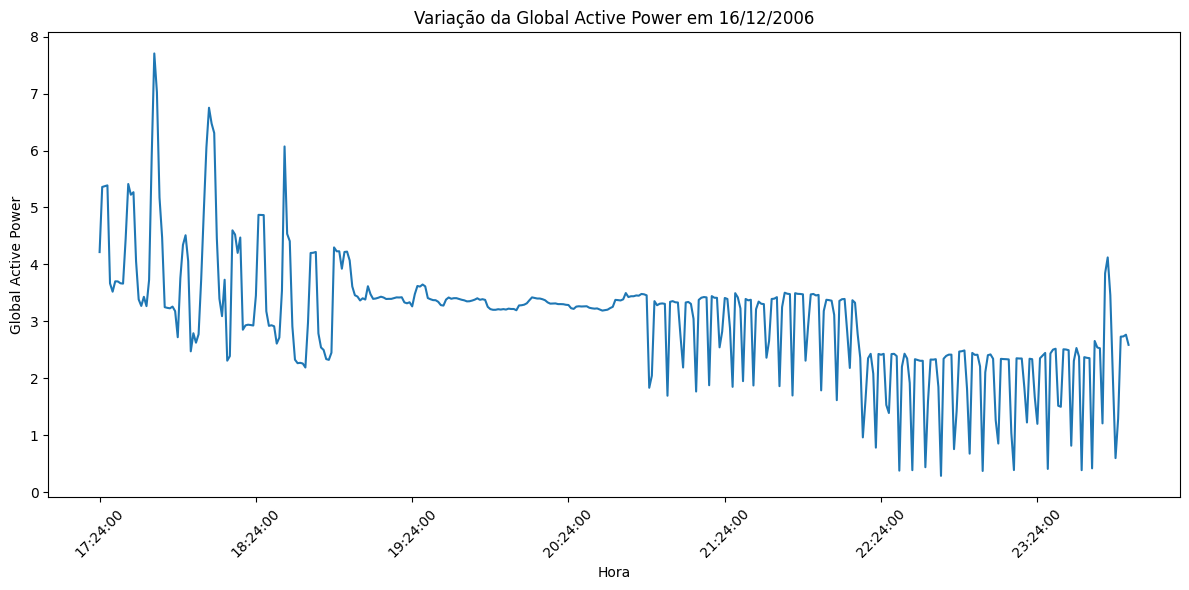

In [ ]:
# Gerar um gráfico de linha com seaborn que mostra a variação da feature Global_ative_power em um único dia
import matplotlib.pyplot as plt

first_day = df['Date'].min()
df_one_day = df[df['Date'] == first_day]

plt.figure(figsize=(12, 6))
sb.lineplot(data=df_one_day, x='Time', y='Global_active_power')
plt.title(f'Variação da Global Active Power em {first_day.strftime("%d/%m/%Y")}')
plt.xlabel('Hora')
plt.ylabel('Global Active Power')
plt.xticks(df_one_day['Time'][::60], rotation=45) # Show ticks every 60 minutes
plt.tight_layout()
plt.show()

 7. Crie um histograma da variável Voltage. O que pode ser observado sobre sua distribuição?

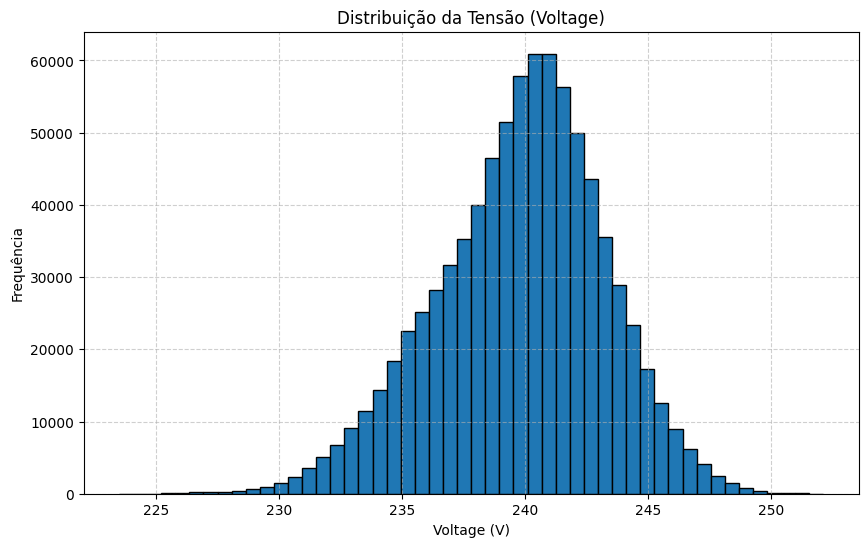

In [ ]:
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

plt.figure(figsize=(10,6))
plt.hist(df['Voltage'].dropna(), bins=50, edgecolor='black')
plt.title('Distribuição da Tensão (Voltage)')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

A distribuição do Voltage é aproximadamente normal, concentrada em torno de 240V, mostrando estabilidade na rede elétrica com pequenas variações e poucos valores extremos.

 8. Calcule o consumo médio por mês em todo o período disponível no dataset.


In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df['YearMonth'] = df['Date'].dt.to_period('M')
media_mensal = df.groupby('YearMonth')['Global_active_power'].mean()

display(media_mensal)

,Global_active_power
YearMonth,
2006-12,1.901295
2007-01,1.546034
2007-02,1.401084
2007-03,1.318627
2007-04,0.891189
2007-05,0.985862
2007-06,0.826814
2007-07,0.667367
2007-08,0.764186


9. Identifique o dia com maior consumo de energia ativa global (Global_active_power).

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

consumo_dia = df.groupby('Date')['Global_active_power'].sum()

dia_max = consumo_dia.idxmax()
valor_max = consumo_dia.max()

print(f"O dia de maior consumo foi {dia_max.strftime('%d/%m/%Y')} com {valor_max:.2f} kW")

O dia de maior consumo foi 23/12/2006 com 4773.39 kW


10. Compare o consumo médio de energia ativa global em dias de semana versus finais de
 semana.

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

media_semana_vs_fim = df.groupby(df['Day_of_Week'].isin(['Saturday', 'Sunday']).map({False: 'Dias de semana', True: 'Fins de semana'}))['Global_active_power'].mean()

print(media_semana_vs_fim)

Day_of_Week
Dias de semana    1.071038
Fins de semana    1.339882
Name: Global_active_power, dtype: float64


11 - Calcule a correlação entre as variáveis Global_active_power, Global_reactive_power, Voltage e Global_intensity.

In [ ]:

cols_to_numeric = ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

correlation = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].corr()
display(correlation)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
Global_active_power,1.000000,0.260296,-0.387466,0.999026
Global_reactive_power,0.260296,1.000000,-0.113424,0.276456
Voltage,-0.387466,-0.113424,1.000000,-0.398021
Global_intensity,0.999026,0.276456,-0.398021,1.000000


12 - Crie uma nova variável chamada Total_Sub_metering que some Sub_metering_1, Sub_metering_2 e Sub_metering_3.

In [ ]:
df['Total_Sub_metering'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
display(df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Total_Sub_metering']].head())

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Sub_metering
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


13 - Verifique se há algum mês em que Total_Sub_metering ultrapassa a média de Global_active_power.

In [ ]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['Global_active_power', 'Total_Sub_metering']].mean()

display(monthly_avg)

months_exceeding_average = monthly_avg[monthly_avg['Total_Sub_metering'] > monthly_avg['Global_active_power']]

if not months_exceeding_average.empty:
    print("\nMonths where Total_Sub_metering exceeds the average Global_active_power:")
    display(months_exceeding_average)
else:
    print("\nThere are no months where Total_Sub_metering exceeds the average Global_active_power.")


,Global_active_power,Total_Sub_metering
Month,,
1,1.502977,10.104865
2,1.289308,8.957880
3,1.281982,9.833878
4,1.008642,8.268648
5,1.005071,8.735948
6,0.910496,8.577771
7,0.721280,6.394702
8,0.764186,6.979336
9,0.969318,8.206236



Months where Total_Sub_metering exceeds the average Global_active_power:


,Global_active_power,Total_Sub_metering
Month,,
1,1.502977,10.104865
2,1.289308,8.957880
3,1.281982,9.833878
4,1.008642,8.268648
5,1.005071,8.735948
6,0.910496,8.577771
7,0.721280,6.394702
8,0.764186,6.979336
9,0.969318,8.206236


14 - Faça um gráfico de série temporal do Voltage para o ano de 2008.

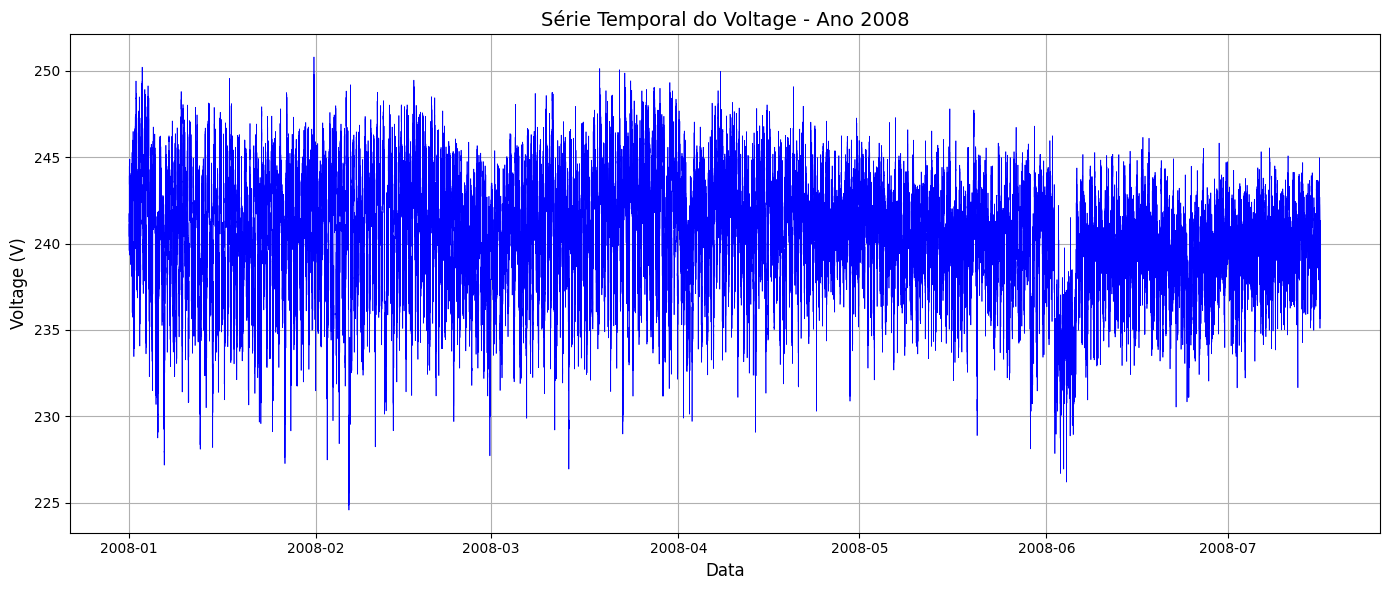

In [ ]:
# Converter Date e Time para datetime
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'],
                                 format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Converter Voltage para numérico
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

# Filtrar apenas o ano de 2008
df_2008 = df[df['DateTime'].dt.year == 2008]

# Plotar gráfico de série temporal
plt.figure(figsize=(14,6))
plt.plot(df_2008['DateTime'], df_2008['Voltage'], color='blue', linewidth=0.5)

plt.title("Série Temporal do Voltage - Ano 2008", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

15 - Compare o consumo entre os meses de verão e inverno (no hemisfério norte).

In [ ]:
summer_months = [6, 7, 8]  # June, July, August
winter_months = [12, 1, 2] # December, January, February

summer_consumption = df[df['Month'].isin(summer_months)]['Global_active_power'].mean()
winter_consumption = df[df['Month'].isin(winter_months)]['Global_active_power'].mean()

print(f"Average Global Active Power in Summer (Northern Hemisphere): {summer_consumption:.2f}")
print(f"Average Global Active Power in Winter (Northern Hemisphere): {winter_consumption:.2f}")

if summer_consumption > winter_consumption:
    print("\nAverage power consumption is higher in summer than in winter.")
elif winter_consumption > summer_consumption:
    print("\nAverage power consumption is higher in winter than in summer.")
else:
    print("\nAverage power consumption is similar in summer and winter.")

Average Global Active Power in Summer (Northern Hemisphere): 0.81
Average Global Active Power in Winter (Northern Hemisphere): 1.49

Average power consumption is higher in winter than in summer.
